In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Nonlinear data

Imagine if instead the linearity assumption was not satisfied. As as example, we can use the data in the `data/tea/` folder, which contains the temperature of a cup of tea at different intervals of time.

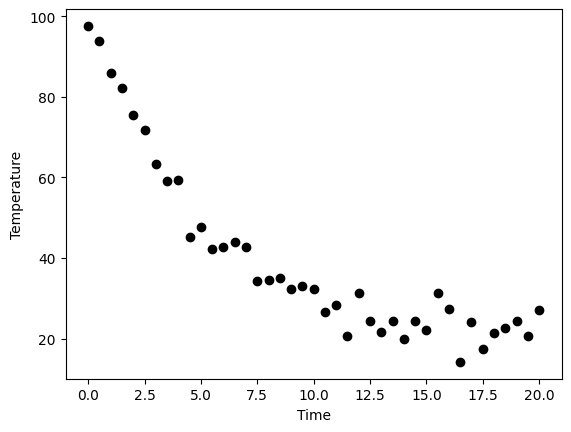

In [5]:
X = np.load('tea/x.npy')
y = np.load('tea/y.npy')

plt.scatter(X, y, color='k')
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

Recall that the temperature of the tea in the cup evolves according to:
$$y(t) = T + (T_0 - T) \exp{-kT}$$

where:

- $T$ is the ambient temperature
- $T_0$ is the initial temperature of the tea
- $k$ is the heat exchange coefficient

We can write a function to evaluate the temperature at a given time, but in this case we do not know $T$, $T_0$ and $k$.
We can collect those values in a vector $\theta$, where:
$$\theta = \begin{pmatrix} T_0 \\ k \\ T \end{pmatrix}$$

Since we don't know them, we can _guess_...

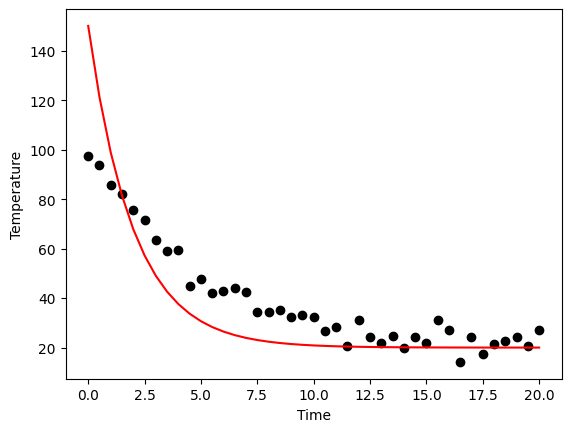

In [15]:
def tea_temperature(theta) -> float:
    return (theta[0]-theta[2]) * (np.exp(-theta[1] * X)) + theta[2]

theta = np.array([150,0.5,20])
# Theta can be defined as you wish, but you can follow notation in the cell

yy = tea_temperature(theta)

plt.plot(X, yy, color='r')
plt.scatter(X, y, color='k')
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

We can formulate the problem mathematically as an optimization problem, where we wish to find $\theta^*$ such that the sum of the squared distances between the real temperatures $y$ and the output of the model $\hat{y}$ are minimal (i.e., we have "good" parameters)

In [18]:
def obj_fun(theta, *args):
    y_pred = tea_temperature(theta)
    y_true = y
    return np.sum((y_true - y_pred)**2)

In [19]:
from scipy.optimize import minimize

# This is given, but please read the documentation
res = minimize(obj_fun, (100, 0.1, 20), method='Nelder-Mead')

In [20]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 489.42397269435764
             x: [ 1.014e+02  2.082e-01  1.989e+01]
           nit: 111
          nfev: 200
 final_simplex: (array([[ 1.014e+02,  2.082e-01,  1.989e+01],
                       [ 1.014e+02,  2.082e-01,  1.989e+01],
                       [ 1.014e+02,  2.082e-01,  1.989e+01],
                       [ 1.014e+02,  2.082e-01,  1.989e+01]]), array([ 4.894e+02,  4.894e+02,  4.894e+02,  4.894e+02]))

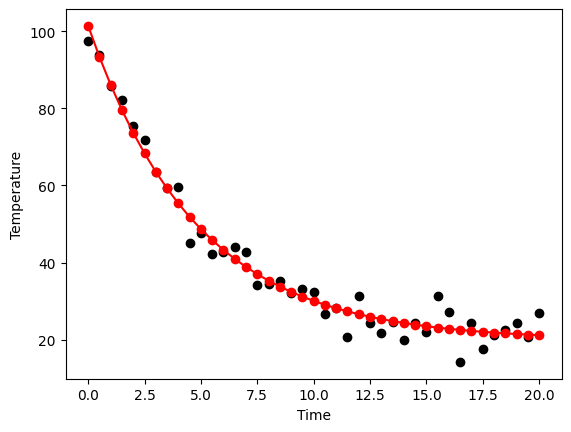

In [21]:
theta = res.x
yy = tea_temperature(theta)

plt.scatter(X, y, color='k')
plt.scatter(X, yy, color='r')
plt.plot(X, yy, color='r')
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()